# BÀI TẬP: EDA HOÀN CHỈNH — TITANIC
## Data Profiling → Descriptive Statistics → Define the Question
**Nguồn:** kaggle.com/c/titanic (891 dòng)

```
PHẦN A — DATA PROFILING       : dữ liệu sạch chưa, có gì
PHẦN B — DESCRIPTIVE STATS    : từng biến trông như thế nào
PHẦN C — DEFINE THE QUESTION  : đặt câu hỏi kinh doanh, trả lời bằng code, rút insight
```

## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
# TODO
print(df.size)
print(df.columns.to_list())
print(df.dtypes)


13365
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class           object
who             object
adult_male        bool
deck            object
embark_town     object
alive           object
alone             bool
dtype: object


## A.2. Missing values & Duplicate data

In [ ]:
# TODO
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing>0] if missing.sum()>0 else "Không có cột nào thiếu dữ liệu.")
print("Duplicate toan bo", df.duplicated().sum())

Missing values:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64
107


## A.3. Invalid values

In [5]:
# TODO
print("fare <= 0:", (df['fare']<=0).sum())
print("age <= 0:", (df['age']<=0).sum())
print("Pclass ngoài [0,1]:", ((df['pclass']<0)|(df['pclass']>1)).sum())
print("=> Dữ liệu khá sạch: age & pclass hợp lệ; có 15 dòng fare=0 cần xem xét")

fare <= 0: 15
age <= 0: 0
Pclass ngoài [0,1]: 675
=> Dữ liệu khá sạch: không missing, không duplicate, không giá trị vô lý.


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [8]:
# TODO
df['family_size'] = df['sibsp'] + df['parch'] + 1
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  family_size  
0    man        True  NaN  Southampton    no  False            2  
1  woman       False    C    Cherbourg   yes  False            2  
2  woman       False  NaN  Southampton   yes   True            1  
3  woman       False    C  Southampton   yes  False            2  
4    man        True  NaN  Southampton    no   True            1  


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [9]:
# TODO
for col in ['age','fare']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_:.2f}, Median={median_:.2f}, Mode={mode_:.2f}")



age: Mean=29.70, Median=28.00, Mode=24.00
fare: Mean=32.20, Median=14.45, Mode=8.05


## Group 2 — Dispersion

In [10]:
# TODO
for col in ['age','fare']:
    s = df[col]
    range_ = s.max()-s.min()
    std_ = s.std()
    q1,q3 = s.quantile([0.25,0.75]); iqr = q3-q1
    cv = std_/s.mean()
    print(f"--- {col} ---")
    print(f"Range={range_:.2f}, Std={std_:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")

--- age ---
Range=79.58, Std=14.53, IQR=17.88, CV=0.49
--- fare ---
Range=512.33, Std=49.69, IQR=23.09, CV=1.54


## Group 3 — Location and Shape

--- age ---
P25=20.12, P50=28.00, P75=38.00
Skewness=nan, Kurtosis=nan
--- fare ---
P25=7.91, P50=14.45, P75=31.00
Skewness=4.78, Kurtosis=33.20


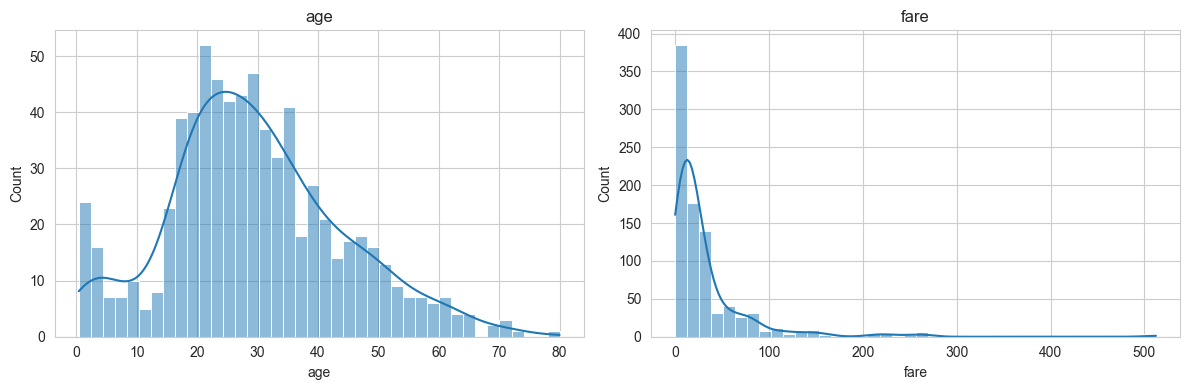

Nhận xét: Fare lệch phải và có kurtosis cao hơn hẳn Age -> nhiều outlier về giá vé cực đoan hơn.


In [12]:
# TODO
for col in ['age','fare']:
    s = df[col]
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")

fig,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(df['age'],bins=40,kde=True,ax=axes[0]); axes[0].set_title('age')
sns.histplot(df['fare'],bins=40,kde=True,ax=axes[1]); axes[1].set_title('fare')
plt.tight_layout(); plt.show()

print("Nhận xét: Fare lệch phải và có kurtosis cao hơn hẳn Age -> nhiều outlier về giá vé cực đoan hơn.")

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

In [9]:
# TODO


## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [10]:
# TODO


## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

In [11]:
# TODO


## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

In [13]:
# TODO
print(df.groupby('family_size')['survived'].mean())

family_size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: survived, dtype: float64


## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [13]:
# TODO


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

*(Viết insight của bạn vào đây...)*